In [5]:
#!/usr/bin/env python3
import sys
sys.path.append( '../../ciphers/AES_python' )
sys.path.append( '../../sca_python' )
import os
os.system("pip list | grep chipwhisperer")
from CW305_api import CW305Wrapper
from pico_api import PS5000aWrapper
from AES_golden import AES_golden_model
import chipwhisperer as cw
import chipwhisperer.analyzer as cwa
from chipwhisperer.common.traces import Trace
from AES_golden import AES_golden_model
import time
from tqdm import tqdm
from analyzer.attack.aes.SBox_leakage_models import AES128SboxResistantLeakageModels
import matplotlib.pyplot as plt
import numpy as np

# Added for multiprocessing support
from multiprocessing import Pool

chipwhisperer                     5.7.0


In [6]:
###################### INITIALIZATION ######################

trace_acquisition = True

"""
Available S-boxes:
    sbox_rijandael (default AES S-Box) (aes_sbox)
    sbox_freyre_1
    sbox_freyre_2
    sbox_freyre_3
    sbox_hussain_6
    sbox_ozkaynak_1
    sbox_azam_1
    sbox_azam_2
    sbox_azam_3
"""
tested_sbox = "sbox_rijandael"
sbox_id = tested_sbox.replace("sbox_", "")

# An already generated bitstream is available in the repository at the path:
bitstream = r"../../../hw/fpga/bitstream/aes/aes_single_round/cw305_top_"+sbox_id+"_lut.bit"
# Used the project data structure (by chipwhisperer) to store SCA data
project_file = "../notebook/examples/aes/traceset/AES_SR_"+sbox_id+".cwp"

print()
print("bitstream: ", bitstream)
print("project_file: ", project_file)
print()

###################### ONLINE PHASE ######################
# 1. Initializing the picoscope
# 2. Initializing the CW305 board with the required parameters
# 3. Loading the bitstream of AES single round to the FPGA

# Number of traces to capture
n_trc = 2000

# Trace acquisition
if trace_acquisition:
    try:
        # Initialize picoscope
        ps = PS5000aWrapper()
        ps.scope_setup()
    except Exception as e:
        print("Error during Picoscope initialization: ", e)
        exit(1)
    try:
        # Initialize CW305
        cw305 = CW305Wrapper(ps, bitstream)
    except Exception as e:
        print("Error during CW305 initialization: ", e)
        ps.dis()
        exit(1)
    # Setup configuration prints 
    print("Picoscope initialized: \n")
    print(ps.get_unitInfo())
    print(ps.get_scopeSettings())
    print("Sampling Interval: ", ps.get_samplingInterval(), "s")
    # Initialize key,text pair generator
    ktp = cw.ktp.Basic()
    key, pt = ktp.next()
    # Initialize the AES software emulated cipher
    cipher = AES_golden_model()
    # Each element of the key is converted to a 2-digit hex string 
    formatted_key = ''.join(format(el, '02x') for el in key)
    print("Key: ", [ hex(subkey) for subkey in key])
    # Write the key to the CW305
    cw305.set_key(key)
    # Dummy capture call due to bug of using AC coupling
    cw305.capture_trace(pt)
    # Create a new project to store the traces
    project = cw.create_project(project_file, overwrite=True)
    # Capture traces loop
    for i in tqdm(range(n_trc), desc="Capturing traces"):
        ct, trace = cw305.capture_trace(pt)
        # Sanity check with expected ciphertext
        formatted_pt = (format(el, '02x') for el in pt)
        text = [int(subbyte, 16) for subbyte in formatted_pt]
        assert (list(ct) == list(cipher.encrypt(formatted_key, text, tested_sbox))), "Incorrect encryption result!\nGot {}\nExp {}\n".format(list(ct), list(pt))
        trace_struct = Trace(trace, pt, ct, key)
        project.traces.append(trace_struct)
        # Get next pt to ecnrypt
        if (i < n_trc-1):
            _ , pt = ktp.next() 
    project.save()
    project.close()

    # Disconnect CW305 and picoscope
    cw305.dis()
    ps.dis()


bitstream:  ../../../hw/fpga/bitstream/aes/aes_single_round/cw305_top_rijandael_lut.bit
project_file:  ../notebook/examples/aes/traceset/AES_SR_rijandael.cwp



(ChipWhisperer Target WARNING|File CW305.py:345) Verilog defines not found in default location (/home/mattia-mirigaldi/.pyenv/versions/cw/lib/python3.9/site-packages/chipwhisperer/../../hardware/victims/cw305_artixtarget/fpga/common/cw305_defines.v).
Using defines from CW305.py.If this isn't what you want, either add 'slurp=False', or provide defines location in 'defines_files'


True
Picoscope initialized: 

Found the following picoscope:
DriverVersion                 : PS5000A Linux Driver, 2.2.10.5074
USBVersion                    : 3.0
HardwareVersion               : 1
VariantInfo                   : 5244D
BatchAndSerial                : 11768/0019
CalDate                       : 24Feb25
KernelVersion                 : 0.0
DigitalHardwareVersion        : 1
AnalogueHardwareVersion       : 1
PicoFirmwareVersion1          : 1.7.15.0
PicoFirmwareVersion2          : 1.2.36.0
None
Nsamples :  1612
Sampling interval = %f us 2e-09
Channel A settings:  Channel A: Range = 50mV, AC coupling, 20 MHz BW limit
Channel B settings:  Channel B: Range = 10V, DC coupling, trigger
None
Sampling Interval:  2e-09 s
Key:  ['0x2b', '0x7e', '0x15', '0x16', '0x28', '0xae', '0xd2', '0xa6', '0xab', '0xf7', '0x15', '0x88', '0x9', '0xcf', '0x4f', '0x3c']


Capturing traces: 100%|██████████| 2000/2000 [02:19<00:00, 14.33it/s]


Analyzing traces (this might take a while)...
Generating success rate plot...


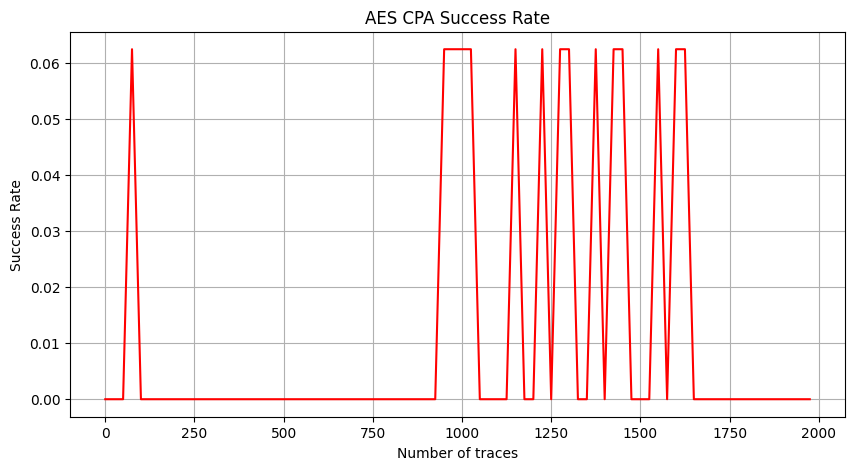

[LOG] OFFLINE PHASE: Computation completed in 3.10 minutes.


In [7]:
####################### OFFLINE PHASE #######################



print("Analyzing traces (this might take a while)...")

# To calculate the success rate, an incremental number of traces is used.
# The idea is that the total number of traces is first divided into N groups (e.g first only 500 traces,
# then 1000 traces, then 1500 traces and so on), then a CPA attack is performed
# on each group of traces and the success rate is calculated on each key byte (i.e. SR[key_byte] = 1
# if guessed_key_byte == correct_key_byte, otherwise SR[key_byte] = 0).
# Then, the success rate of the whole attack is calculated as the average of the success rates of each key byte,
# i.e. SR = (SR[0] + SR[1] + ... + SR[15]) / 16 (16 since for AES128 the key size is 128 bit or 16 bytes).
# The ChipWhisperer Analyzer is used to perform the CPA attack on the traces. It returns the list of the guessed
# key bytes and it supports the use of a callback function to get the statistics of the attack, which is used 
# to calculate the success rate. The callback function "resolution" parameter is used to define how often
# the statistics are updated (e.g. every 25 traces), so it basically works also as traces slicer.
# Each time the callback function is called, the guessed key bytes are compared with the correct key bytes
# and the success rate is updated. The final success rate is then plotted using matplotlib.

# Performance metrics
tic = time.perf_counter()

# Initialize the success rate list
success_rate = []

# The resolution defines how many traces are added each time to evaluate the n-success_rate.
resolution = 25

def success_rate_callback():
    global success_rate
    global key

    # Get the attack results (guessed key bytes).
    # The "find_maximums" method returns 3 nested lists:
    # 1. The first list contains the guessed key bytes ordered by subkey index
    #    [subkey0_data, subkey1_data, subkey2_data, ...]
    # 2. subkey0_data is another list containing guesses ordered by strength of correlation:
    #    [guess0, guess1, guess2, ...]
    # 3. guess0 is a tuple containing:
    #    (key_guess, location_of_max, correlation)
    # So, with the syntax kguess[0][0], we get the best key guess for each subkey.
    results = attack.results
    guessed_key = [kguess[0][0] for kguess in results.find_maximums()]
    
    iteration_success_rate = []
    # Compare the guessed key bytes with the correct key bytes
    for key_byte, guessed_key_byte in zip(key, guessed_key):
        # If the guessed key byte matches the correct key byte, i-th success_rate is 1, otherwise 0
        success_rate_i = 1 if key_byte == guessed_key_byte else 0
        iteration_success_rate.append(success_rate_i)

    # Calculate the average success rate for the current iteration
    avg_success_rate = sum(iteration_success_rate) / len(iteration_success_rate)
    # Append the average success rate to the success_rate list
    success_rate.append(avg_success_rate)


# Attack loop
project = cw.open_project(project_file)
# The Hamming Weight is used as the leakage model for the CPA attack.
leak_model = AES128SboxResistantLeakageModels().LastroundStateDiff_ModifiedSbox(tested_sbox)
attack = cwa.cpa(project, leak_model)
# Perform the CPA attack
attack.run(success_rate_callback, resolution)
project.close()


# Success Rate plot with matplotlib
print("Generating success rate plot...")

xrange = [i * resolution for i in range(len(success_rate))]
# xrange = range(len(success_rate))
plt.figure(figsize=(10, 5))
plt.plot(xrange, success_rate, color="red")
plt.xlabel("Number of traces")
plt.ylabel("Success Rate")
plt.title("AES CPA Success Rate")
plt.grid(True)
plt.savefig("../../notebook/examples/aes/Graphs/AES_cpa_success_rate_" + sbox_id + ".pdf", dpi=300)
plt.show()


toc = time.perf_counter()
print(f"[LOG] OFFLINE PHASE: Computation completed in {(toc - tic)/60:0.2f} minutes.")
